<a href="https://colab.research.google.com/github/raghavrakesh20/Small-projects-practice./blob/main/Rakesh_FInal_Work_file.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Block 1. Install environment
!pip -q install huggingface_hub opencv-python-headless

import numpy as np
import cv2

def filter_structural_edges(edge_mask, min_area=80):
    """
    Isolates architecture by removing small pixel clusters (text/noise).
    min_area: Minimum pixel count for a shape to be considered 'architecture'.
    """
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(edge_mask, connectivity=8)
    clean_edges = np.zeros_like(edge_mask)

    # Loop through all detected shapes, skipping the background (0)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            clean_edges[labels == i] = 255

    return clean_edges

# Block 2. Download the manually matched pair folder from Hugging Face
from pathlib import Path
from huggingface_hub import snapshot_download

# ==========================================
# REPOSITORY SETTINGS
# ==========================================
REPO_ID = "ShunxingFan/shixue-perspectiva-dashboard-assets"
SUBFOLDER = "manually_matched_pairs_36_renamed"
LOCAL_ROOT = Path("hf_checked_pairs_download")
DATA_DIR = LOCAL_ROOT / SUBFOLDER

if DATA_DIR.exists():
    print(f"✅ Using cached local folder: {DATA_DIR}")
else:
    print("⏳ Downloading images from Hugging Face. Please wait...")
    try:
        snapshot_download(
            repo_id=REPO_ID,
            repo_type="dataset", # <--- IF THIS FAILS, CHANGE "dataset" to "space"
            local_dir=LOCAL_ROOT,
            allow_patterns=[f"{SUBFOLDER}/**"], # Added ** to ensure all files are grabbed
        )
        print("✅ Download complete!")
    except Exception as exc:
        print(f"\n❌ HUGGING FACE ERROR: {exc}\n")
        raise RuntimeError(
            "Could not download the folder. Read the HUGGING FACE ERROR above to see why."
        ) from exc

MANIFEST_CSV = DATA_DIR / "pairs_manifest.csv"

print(f"Data directory: {DATA_DIR}")
print(f"Manifest exists: {MANIFEST_CSV.exists()}")

⏳ Downloading images from Hugging Face. Please wait...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching ... files: 0it [00:00, ?it/s]

✅ Download complete!
Data directory: hf_checked_pairs_download/manually_matched_pairs_36_renamed
Manifest exists: True


📖 Reading the Dataset Manifest...
⚙️ Calculating Pure Translational Delta for all 36 pairs. Please wait...


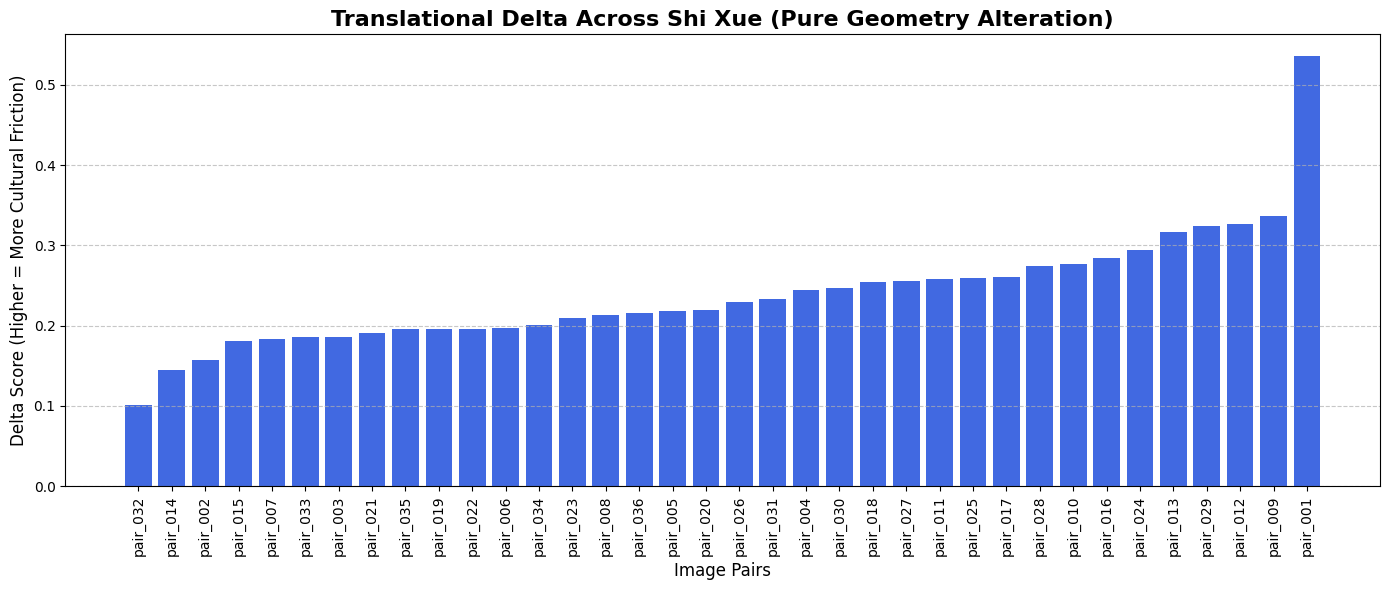

In [2]:
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from pathlib import Path

# === THE NOISE FILTER (Purges Text and Artifacts) ===
def filter_structural_edges(edge_mask, min_area=80):
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(edge_mask, connectivity=8)
    clean_edges = np.zeros_like(edge_mask)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            clean_edges[labels == i] = 255
    return clean_edges
# ====================================================

# 1. Setup and Load Manifest
DATA_DIR = Path("hf_checked_pairs_download/manually_matched_pairs_36_renamed")
MANIFEST_CSV = DATA_DIR / "pairs_manifest.csv"

print("📖 Reading the Dataset Manifest...")
try:
    df = pd.read_csv(MANIFEST_CSV)
except FileNotFoundError:
    print(f"❌ ERROR: Could not find {MANIFEST_CSV}")
    df = None

if df is not None:
    col_chinese = 'chinese_filename'
    col_latin = 'latin_filename'
    results = []

    print("⚙️ Calculating Pure Translational Delta for all 36 pairs. Please wait...")

    # 2. The Core Processing Loop
    for index, row in df.iterrows():
        chinese_file = str(row[col_chinese])
        latin_file = str(row[col_latin])

        img_chinese = cv2.imread(str(DATA_DIR / chinese_file), cv2.IMREAD_GRAYSCALE)
        img_latin = cv2.imread(str(DATA_DIR / latin_file), cv2.IMREAD_GRAYSCALE)

        if img_chinese is not None and img_latin is not None:
            # Step A: Align Dimensions
            img_chinese_aligned = cv2.resize(img_chinese, (img_latin.shape[1], img_latin.shape[0]))

            # Step B: Extract Raw Geometry (Ink)
            edges_latin_raw = cv2.Canny(img_latin, 50, 150)
            edges_chinese_raw = cv2.Canny(img_chinese_aligned, 50, 150)

            # Step C: Purge Text Noise (Isolate Architecture)
            edges_latin = filter_structural_edges(edges_latin_raw, min_area=80)
            edges_chinese = filter_structural_edges(edges_chinese_raw, min_area=80)

            # Step D: Apply Historical Tolerance (Blur medium artifacts)
            edges_latin = cv2.GaussianBlur(edges_latin, (3, 3), 0)
            edges_chinese = cv2.GaussianBlur(edges_chinese, (3, 3), 0)

            # Step E: Calculate pure structural friction
            score, _ = ssim(edges_latin, edges_chinese, full=True)
            delta = 1 - score

            pair_label = str(row['pair_id'])
            results.append({"Pair": pair_label, "Delta": delta})
        else:
            print(f"⚠️ Warning: Could not load images for {chinese_file} or {latin_file}. Skipping.")

    # 3. Visualize the Clean Data
    if len(results) > 0:
        results_df = pd.DataFrame(results)
        results_df = results_df.sort_values(by="Delta")

        plt.figure(figsize=(14, 6))
        plt.bar(results_df["Pair"], results_df["Delta"], color='royalblue')
        plt.xticks(rotation=90)
        plt.title("Translational Delta Across Shi Xue (Pure Geometry Alteration)", fontsize=16, fontweight="bold")
        plt.ylabel("Delta Score (Higher = More Cultural Friction)", fontsize=12)
        plt.xlabel("Image Pairs", fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

✅ Images loaded successfully! Generating Cartography Map...


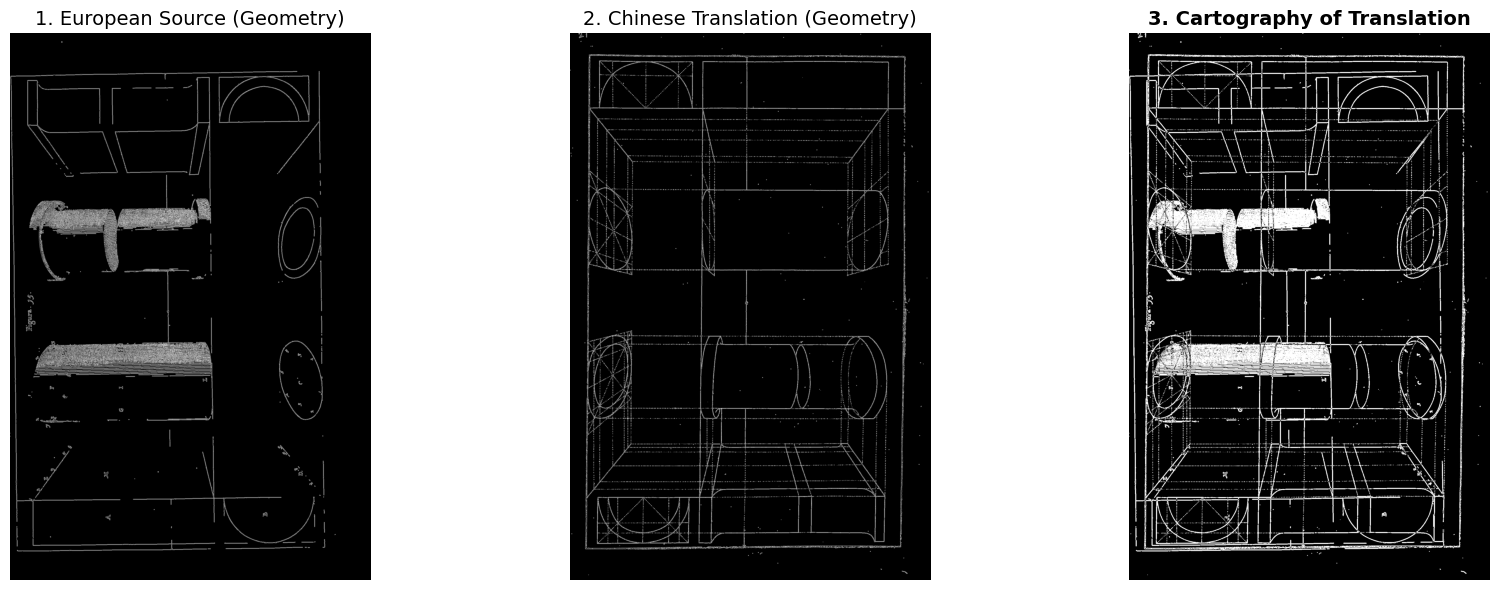

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ==========================================
# 1. POINT TO THE HUGGING FACE FOLDER
# ==========================================
DATA_DIR = Path("hf_checked_pairs_download/manually_matched_pairs_36_renamed")

# ==========================================
# 2. SET YOUR IMAGE NAMES HERE
# ==========================================
# These must match the names inside your dataset
latin_filename = "page_15_latin.png"
chinese_filename = "page_15_ch.png"

# Build the full, correct file paths
latin_file = str(DATA_DIR / latin_filename)
chinese_file = str(DATA_DIR / chinese_filename)

# ==========================================
# 3. LOAD AND SAFETY CHECK
# ==========================================
img_latin = cv2.imread(latin_file, cv2.IMREAD_GRAYSCALE)
img_chinese = cv2.imread(chinese_file, cv2.IMREAD_GRAYSCALE)

if img_latin is None:
    print(f"❌ CRITICAL ERROR: Could not find the European image at:\n{latin_file}")
elif img_chinese is None:
    print(f"❌ CRITICAL ERROR: Could not find the Chinese image at:\n{chinese_file}")
else:
    print("✅ Images loaded successfully! Generating Cartography Map...")

    # ==========================================
    # 4. ALIGN AND STRIP MEDIUM (The Bones)
    # ==========================================
    img_chinese_aligned = cv2.resize(img_chinese, (img_latin.shape[1], img_latin.shape[0]))

    edges_latin = cv2.Canny(img_latin, 50, 150)
    edges_chinese = cv2.Canny(img_chinese_aligned, 50, 150)

    edges_latin = cv2.GaussianBlur(edges_latin, (3, 3), 0)
    edges_chinese = cv2.GaussianBlur(edges_chinese, (3, 3), 0)

    # ==========================================
    # 5. CALCULATE CULTURAL FRICTION (Heatmap)
    # ==========================================
    diff = cv2.absdiff(edges_latin, edges_chinese)
    _, diff_thresh = cv2.threshold(diff, 50, 255, cv2.THRESH_BINARY)
    heatmap = cv2.applyColorMap(diff_thresh, cv2.COLORMAP_HOT)

    # ==========================================
    # 6. VISUALIZATION
    # ==========================================
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.title("1. European Source (Geometry)", fontsize=14)
    plt.imshow(edges_latin, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("2. Chinese Translation (Geometry)", fontsize=14)
    plt.imshow(edges_chinese, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("3. Cartography of Translation", fontsize=14, fontweight='bold')
    plt.imshow(cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.tight_layout()
    plt.show()

📖 Reading the Dataset Manifest...
⚙️ Calculating Translational Delta for all 36 pairs. Please wait...


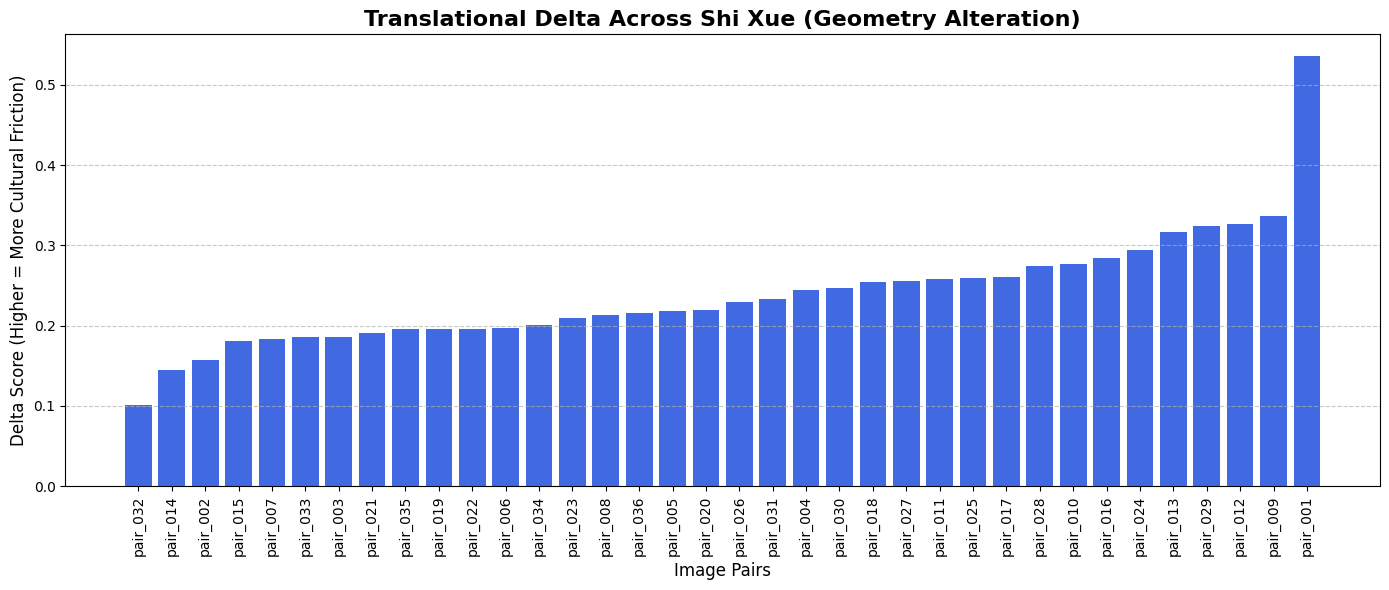


--- ACADEMIC INSIGHTS ---
Most Faithfully Translated (Lowest Delta - The exact geometry was preserved):
    Pair    Delta
pair_032 0.101657
pair_014 0.145153
pair_002 0.157565

Most Culturally Altered (Highest Delta - The geometry was heavily modified/Sinicized):
    Pair    Delta
pair_012 0.326986
pair_009 0.336714
pair_001 0.536208


In [4]:
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from pathlib import Path

# === STEP 1: DEFINE THE MISSING FUNCTION ===
def filter_structural_edges(edge_mask, min_area=80):
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(edge_mask, connectivity=8)
    clean_edges = np.zeros_like(edge_mask)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            clean_edges[labels == i] = 255
    return clean_edges
# ============================================

# 1. Point to your newly downloaded Hugging Face folder
DATA_DIR = Path("hf_checked_pairs_download/manually_matched_pairs_36_renamed")
MANIFEST_CSV = DATA_DIR / "pairs_manifest.csv"

# 2. Read the Manifest
print("📖 Reading the Dataset Manifest...")
try:
    df = pd.read_csv(MANIFEST_CSV)
except FileNotFoundError:
    print(f"❌ ERROR: Could not find {MANIFEST_CSV}")
    df = None

if df is not None:
    col_chinese = 'chinese_filename'
    col_latin = 'latin_filename'
    results = []

    print("⚙️ Calculating Translational Delta for all 36 pairs. Please wait...")

    # 3. The Batch Loop
    for index, row in df.iterrows():
        chinese_file = str(row[col_chinese])
        latin_file = str(row[col_latin])

        chinese_path = DATA_DIR / chinese_file
        latin_path = DATA_DIR / latin_file

        img_chinese = cv2.imread(str(chinese_path), cv2.IMREAD_GRAYSCALE)
        img_latin = cv2.imread(str(latin_path), cv2.IMREAD_GRAYSCALE)

        if img_chinese is not None and img_latin is not None:
            img_chinese_aligned = cv2.resize(img_chinese, (img_latin.shape[1], img_latin.shape[0]))

            # === FIXED INDENTATION HERE ===
            edges_latin_raw = cv2.Canny(img_latin, 50, 150)
            edges_chinese_raw = cv2.Canny(img_chinese_aligned, 50, 150)

            edges_latin = filter_structural_edges(edges_latin_raw, min_area=80)
            edges_chinese = filter_structural_edges(edges_chinese_raw, min_area=80)
            # ==============================

            edges_latin = cv2.GaussianBlur(edges_latin, (3, 3), 0)
            edges_chinese = cv2.GaussianBlur(edges_chinese, (3, 3), 0)

            score, _ = ssim(edges_latin, edges_chinese, full=True)
            delta = 1 - score

            pair_label = str(row['pair_id'])
            results.append({"Pair": pair_label, "Delta": delta})
        else:
            print(f"⚠️ Warning: Could not load images for {chinese_file} or {latin_file}. Skipping.")

    # 4. Save and Visualize the Results
    if len(results) > 0:
        results_df = pd.DataFrame(results)
        results_df = results_df.sort_values(by="Delta")

        plt.figure(figsize=(14, 6))
        plt.bar(results_df["Pair"], results_df["Delta"], color='royalblue')
        plt.xticks(rotation=90)
        plt.title("Translational Delta Across Shi Xue (Geometry Alteration)", fontsize=16, fontweight="bold")
        plt.ylabel("Delta Score (Higher = More Cultural Friction)", fontsize=12)
        plt.xlabel("Image Pairs", fontsize=12)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

        print("\n--- ACADEMIC INSIGHTS ---")
        print("Most Faithfully Translated (Lowest Delta - The exact geometry was preserved):")
        print(results_df.head(3).to_string(index=False))
        print("\nMost Culturally Altered (Highest Delta - The geometry was heavily modified/Sinicized):")
        print(results_df.tail(3).to_string(index=False))
    else:
        print("❌ CRITICAL ERROR: The results list is empty. None of the images loaded.")

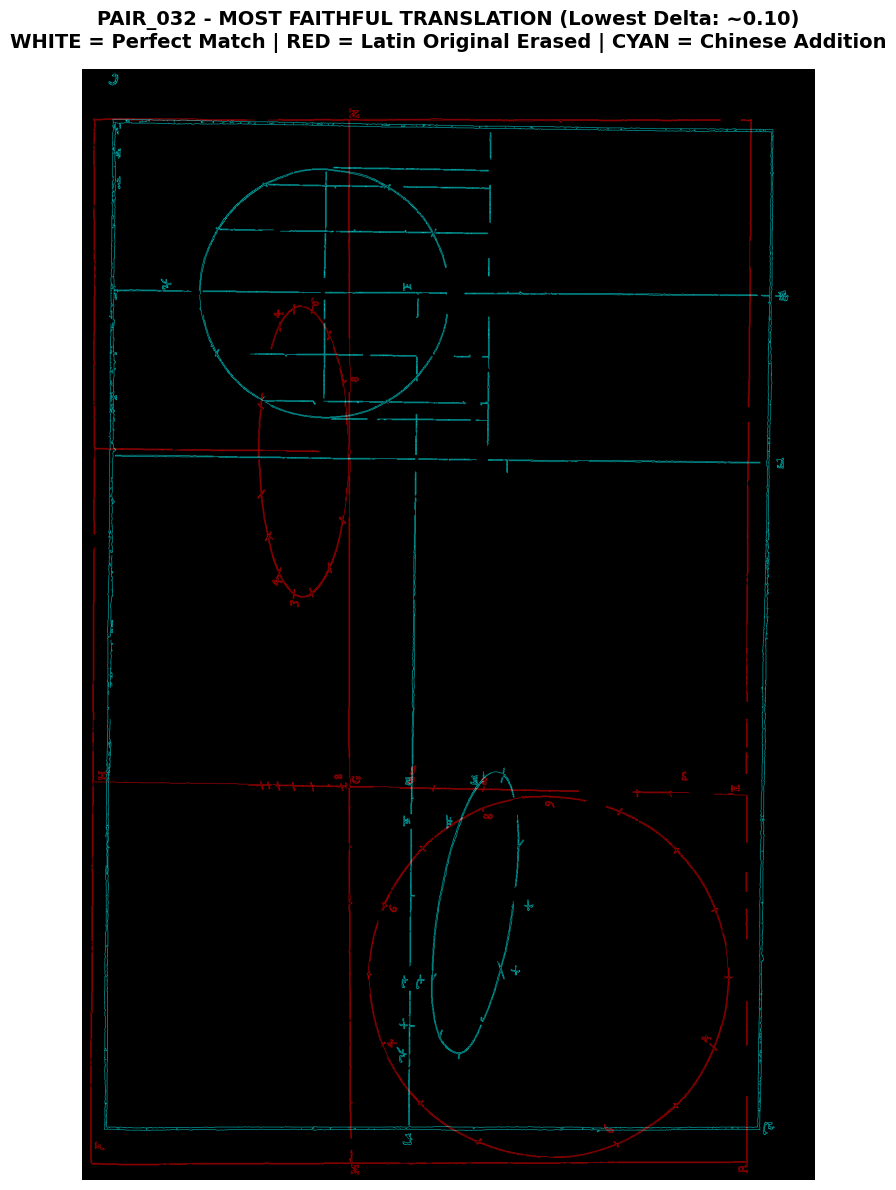

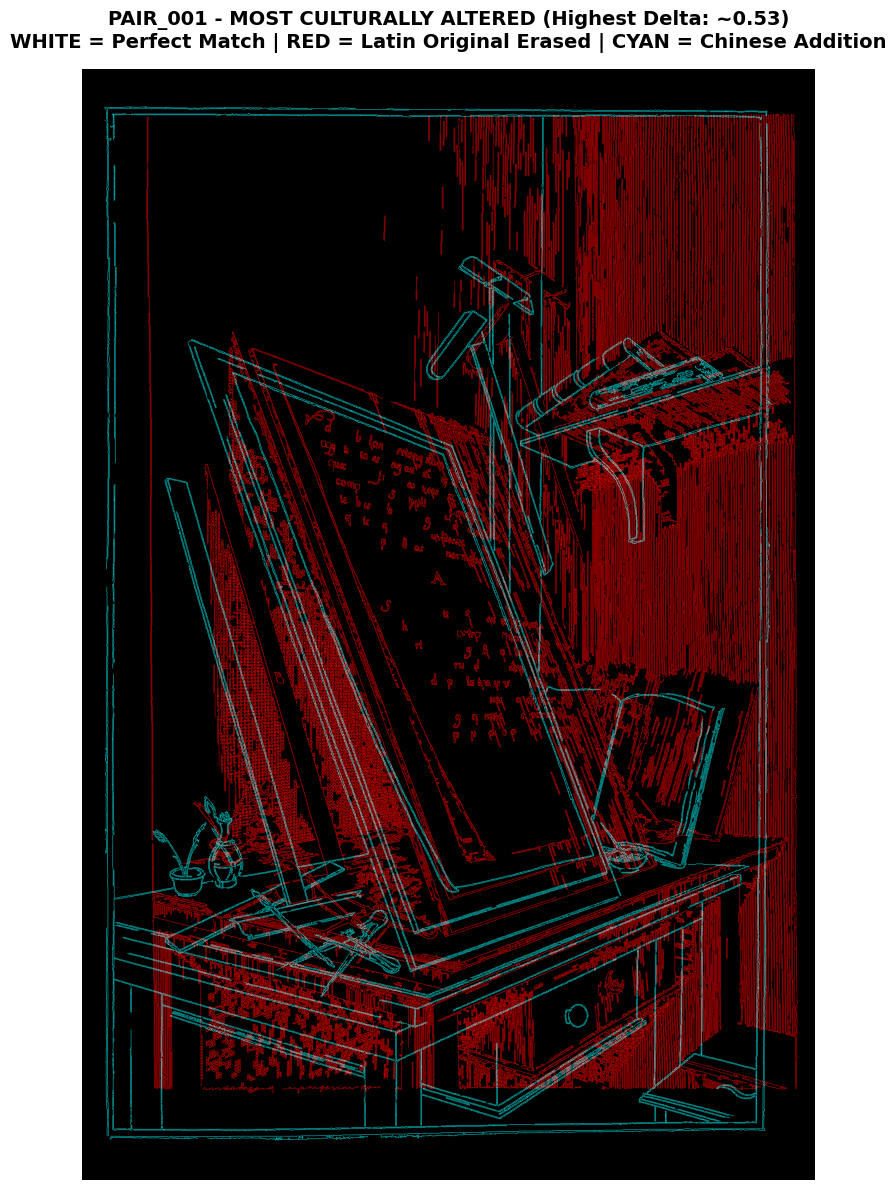

In [5]:
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# === 1. THE NOISE FILTER ===
def filter_structural_edges(edge_mask, min_area=80):
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(edge_mask, connectivity=8)
    clean_edges = np.zeros_like(edge_mask)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            clean_edges[labels == i] = 255
    return clean_edges

# === 2. SETUP PATHS ===
DATA_DIR = Path("hf_checked_pairs_download/manually_matched_pairs_36_renamed")
MANIFEST_CSV = DATA_DIR / "pairs_manifest.csv"

# === 3. TARGET PAIRS TO VISUALIZE ===
# We are grabbing the Most Faithful (pair_032) and Most Altered (pair_001)
target_pairs = [
    {"id": "pair_032", "title": "MOST FAITHFUL TRANSLATION (Lowest Delta: ~0.10)"},
    {"id": "pair_001", "title": "MOST CULTURALLY ALTERED (Highest Delta: ~0.53)"}
]

# Read the manifest to get the exact filenames
try:
    df = pd.read_csv(MANIFEST_CSV)

    for target in target_pairs:
        # Find the row for this specific pair
        row = df[df['pair_id'] == target["id"]]

        if not row.empty:
            latin_file = str(row.iloc[0]['latin_filename'])
            chinese_file = str(row.iloc[0]['chinese_filename'])

            img_latin = cv2.imread(str(DATA_DIR / latin_file), cv2.IMREAD_GRAYSCALE)
            img_chinese = cv2.imread(str(DATA_DIR / chinese_file), cv2.IMREAD_GRAYSCALE)

            if img_latin is not None and img_chinese is not None:
                # Align Dimensions
                img_chinese_aligned = cv2.resize(img_chinese, (img_latin.shape[1], img_latin.shape[0]))

                # Extract and Clean Geometry
                edges_latin_raw = cv2.Canny(img_latin, 50, 150)
                edges_chinese_raw = cv2.Canny(img_chinese_aligned, 50, 150)

                edges_latin = filter_structural_edges(edges_latin_raw, min_area=80)
                edges_chinese = filter_structural_edges(edges_chinese_raw, min_area=80)

                # Create the Visual Heatmap
                heatmap = np.zeros((img_latin.shape[0], img_latin.shape[1], 3), dtype=np.uint8)
                heatmap[:, :, 0] = edges_latin   # Latin in RED
                heatmap[:, :, 1] = edges_chinese # Chinese in CYAN
                heatmap[:, :, 2] = edges_chinese

                # Display the Image
                plt.figure(figsize=(12, 12))
                plt.imshow(heatmap)
                plt.title(f"{target['id'].upper()} - {target['title']}\nWHITE = Perfect Match | RED = Latin Original Erased | CYAN = Chinese Addition",
                          fontsize=14, pad=15, fontweight='bold')
                plt.axis('off')
                plt.tight_layout()
                plt.show()
            else:
                print(f"⚠️ Could not load image files for {target['id']}")
        else:
            print(f"⚠️ Could not find {target['id']} in the CSV.")

except FileNotFoundError:
    print(f"❌ ERROR: Could not find {MANIFEST_CSV}")